In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from google.colab import auth
import gspread
from gspread_dataframe import get_as_dataframe

# --- Load Google Sheet ---
auth.authenticate_user()
from google.auth import default
creds, _ = default()
gc = gspread.authorize(creds)


In [ ]:
url = "https://docs.google.com/spreadsheets/d/1WgJxBz_L6jBvRb94UODX4nLX8Pu-e-_u6Hd2VrQQFbE/edit?gid=0#gid=0"
sheet = gc.open_by_url(url).sheet1
df = get_as_dataframe(sheet).dropna()

X = df[['height_cm','weight_kg']].values
y = df['sport']



In [ ]:
le = LabelEncoder()
y_enc = le.fit_transform(y)

k = 5
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X, y_enc)



KNeighborsClassifier()

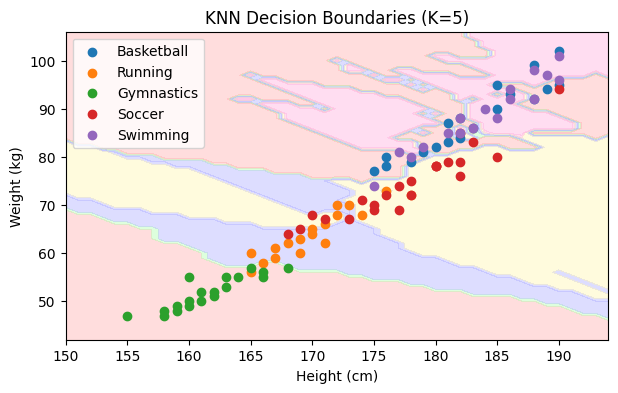

In [ ]:
# Create mesh grid
h = 1.0
x_min, x_max = X[:,0].min() - 5, X[:,0].max() + 5
y_min, y_max = X[:,1].min() - 5, X[:,1].max() + 5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF','#FFF5AA','#FFAADD'])

plt.figure(figsize=(7,4))
plt.contourf(xx, yy, Z, cmap=cmap_light, alpha=0.4)

# Plot original points
for sport in df['sport'].unique():
    subset = df[df['sport'] == sport]
    plt.scatter(subset['height_cm'], subset['weight_kg'], label=sport)

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title(f"KNN Decision Boundaries (K={k})")
plt.legend()
plt.show()